# Exercise E2
Using pandas and the DataFrame object, import the file in the python workspace and write a script to create a new file with the following features:

a proper name, helping you to know what the content is
a first row with the name of each column and the units (where appropriate)

In [1]:
import pandas as pd

# Step 1: Read the raw file (no headers in original)
df = pd.read_csv("for_nitpicker.dat", 
                 sep="\t",   # assuming tab-delimited
                 header=None)

# Step 2: Assign proper column names with units
df.columns = [
    "Date", 
    "Time", 
    "Depth (m)", 
    "Temperature (°C)", 
    "Salinity (psu)"
]

# Step 3: Save to a new file with a descriptive name
df.to_csv("CTD_cast_with_headers.csv", index=False)


## Part 2

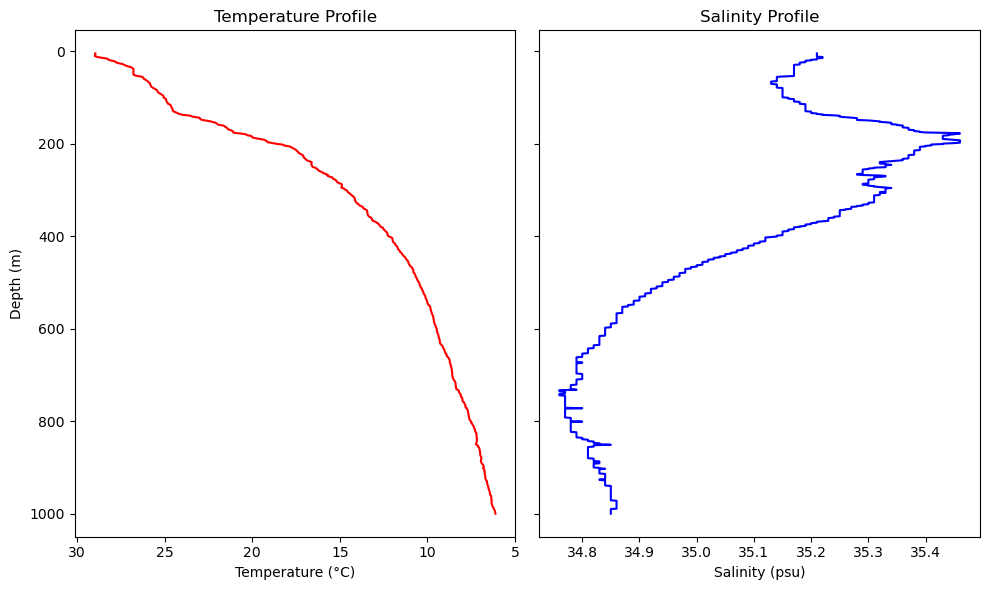

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned CTD file
df = pd.read_csv("CTD_cast_with_headers.csv")

# Create the figure with 1 row, 2 columns, sharing y-axis
fig, ax = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Temperature profile
ax[0].plot(df["Temperature (°C)"], df["Depth (m)"], color="red")
ax[0].set_xlabel("Temperature (°C)")
ax[0].set_ylabel("Depth (m)")
ax[0].set_title("Temperature Profile")
ax[0].invert_xaxis()   # ✅ force depth increasing downward

# Salinity profile
ax[1].plot(df["Salinity (psu)"], df["Depth (m)"], color="blue")
ax[1].set_xlabel("Salinity (psu)")
ax[1].set_title("Salinity Profile")
ax[1].invert_yaxis()   # ✅ force depth increasing downward

plt.tight_layout()
plt.show()


## Part 3

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Step 1:
Load the CSV file in python, using the appropriate column for the time index. Check that the missing values are properly recognized.
The ship reached the southernmost location on July 4th. Use the time indexing to select the data from departure to that date included. All plots will be done using this selected set of data.

In [19]:
file_path = "SAA2_WC_2017_metocean_10min_avg.csv"

In [20]:
df = pd.read_csv(file_path, na_values=['NULL'])

In [21]:
# Convert TIME_SERVER to datetime and set as index
df['TIME_SERVER'] = pd.to_datetime(df['TIME_SERVER'], format='%Y/%m/%d %H:%M')
df.set_index('TIME_SERVER', inplace=True)

In [22]:
start_date = df.index.min()      
end_date = '2017-07-04'            
mask = (df.index >= start_date) & (df.index <= end_date)
df_selected = df.loc[mask].copy()

In [23]:
print(f"Data selected from {start_date.date()} to {end_date}")

Data selected from 2017-06-28 to 2017-07-04


### Step 2
Plot the time series of temperature with the appropriate labels. Save the figure using the 'grayscale' style

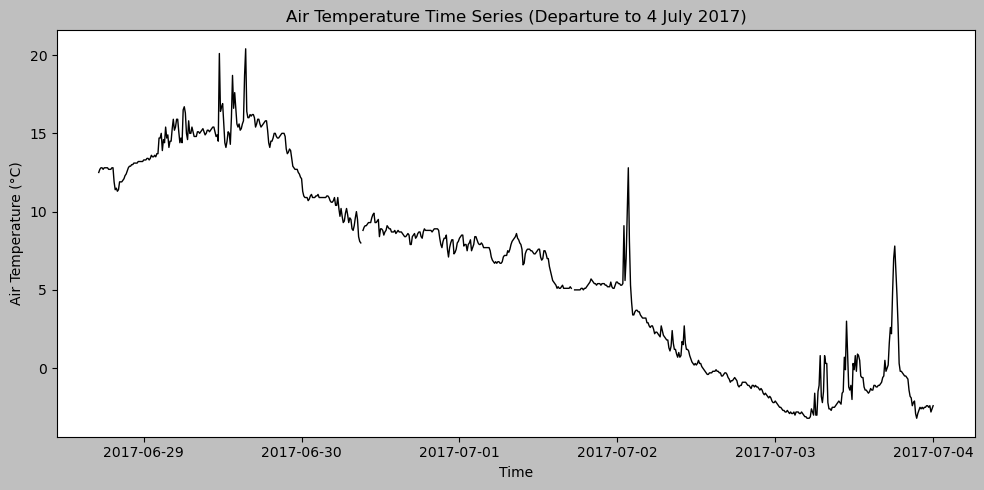

Temperature time series saved as 'temperature_timeseries.png'


In [24]:
plt.style.use('grayscale')
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_selected.index, df_selected['AIR_TEMPERATURE'], linewidth=1)
ax.set_xlabel('Time')
ax.set_ylabel('Air Temperature (°C)')
ax.set_title('Air Temperature Time Series (Departure to 4 July 2017)')
plt.tight_layout()
plt.savefig('temperature_timeseries.png', dpi=300)
plt.show()
print("Temperature time series saved as 'temperature_timeseries.png'")

### Step 3
Plot a histogram of the salinity distribution using bins of 0.5 psu between 30 and 35.

In [25]:
salinity = df_selected['TSG_SALINITY'].dropna()
bins = np.arange(30, 35.5, 0.5)   # bins from 30 to 35 inclusive, step 0.5

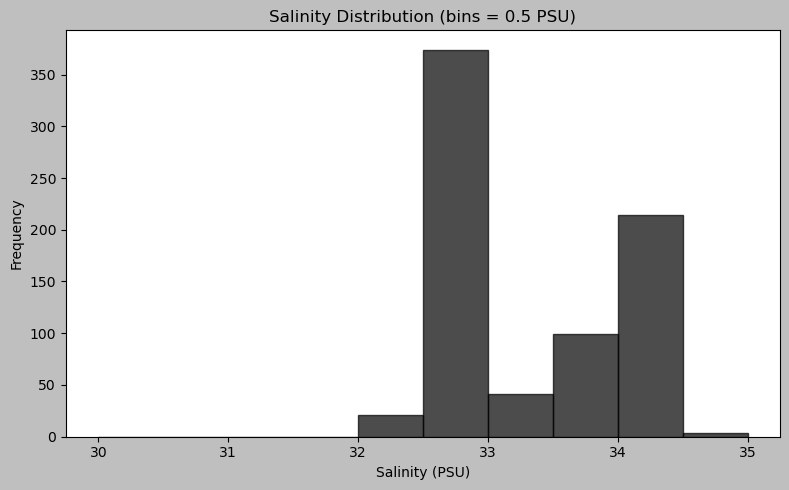

Salinity histogram saved as 'salinity_histogram.png'


In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(salinity, bins=bins, edgecolor='black', alpha=0.7)
ax.set_xlabel('Salinity (PSU)')
ax.set_ylabel('Frequency')
ax.set_title('Salinity Distribution (bins = 0.5 PSU)')
plt.tight_layout()
plt.savefig('salinity_histogram.png', dpi=300)
plt.show()
print("Salinity histogram saved as 'salinity_histogram.png'")

### Step 4
Calculate the mean, standard deviation and the interquartile range for temperature and salinity and present the results in a table.

In [30]:
temp = df_selected['AIR_TEMPERATURE'].dropna()
sal = df_selected['TSG_SALINITY'].dropna()

In [31]:
temp_mean = temp.mean()
temp_std = temp.std()
temp_iqr = temp.quantile(0.75) - temp.quantile(0.25)

In [32]:
sal_mean = sal.mean()
sal_std = sal.std()
sal_iqr = sal.quantile(0.75) - sal.quantile(0.25)

In [33]:
# Create a summary table
stats_table = pd.DataFrame({
    'Variable': ['Air Temperature (°C)', 'Salinity (PSU)'],
    'Mean': [temp_mean, sal_mean],
    'Std Dev': [temp_std, sal_std],
    'IQR': [temp_iqr, sal_iqr]
})
print("\nSummary Statistics Table:")
print(stats_table.to_string(index=False))


Summary Statistics Table:
            Variable     Mean  Std Dev     IQR
Air Temperature (°C)  6.46614 6.098960 10.8500
      Salinity (PSU) 33.35233 0.737574  1.4742


### Step 5
Create a scatter plot of wind speed and air temperature, encoding the latitude information in colour. Wind speed is in meters per second and air temperature in degrees Celsius. Save this figure in PNG with a resolution of 300 DPI

In [34]:
def ddmm2dd(ddmm):
    """Convert DDMM.cccc to decimal degrees."""
    deg = np.floor(ddmm / 100.)
    minutes = (ddmm - deg * 100.) / 60.
    return deg + minutes

In [35]:
df_selected['LAT_DEC'] = df_selected['LATITUDE'].apply(ddmm2dd)
df_selected['LAT_DEC'] = np.where(df_selected['N_S'] == 'S', -df_selected['LAT_DEC'], df_selected['LAT_DEC'])

In [36]:
scatter_data = df_selected[['WIND_SPEED_TRUE', 'AIR_TEMPERATURE', 'LAT_DEC']].dropna()

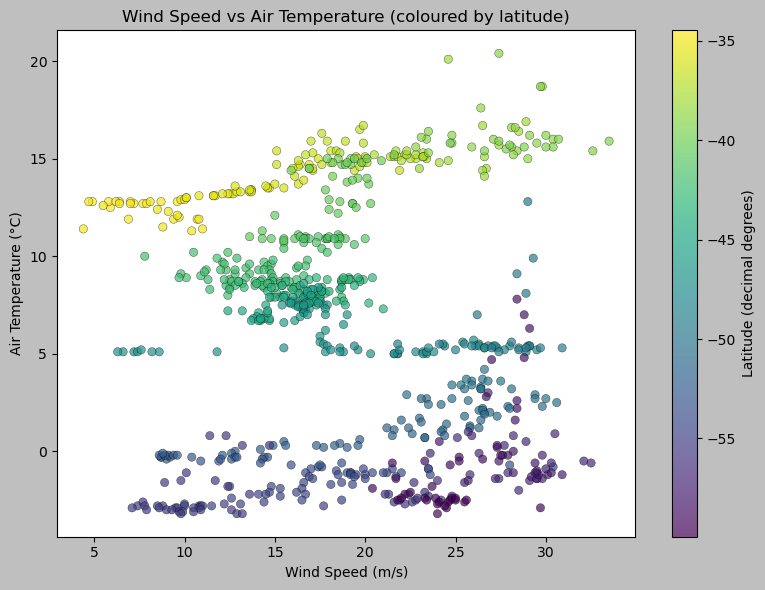

Scatter plot saved as 'wind_temp_scatter.png' (300 DPI)


In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(scatter_data['WIND_SPEED_TRUE'], scatter_data['AIR_TEMPERATURE'],
                c=scatter_data['LAT_DEC'], cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.3)
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Air Temperature (°C)')
ax.set_title('Wind Speed vs Air Temperature (coloured by latitude)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Latitude (decimal degrees)')
plt.tight_layout()
plt.savefig('wind_temp_scatter.png', dpi=300)
plt.show()
print("Scatter plot saved as 'wind_temp_scatter.png' (300 DPI)")